In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_path = '../data/benchmarks.csv'
df = pd.read_csv(file_path)

trial_cols = ['1', '2', '3', '4', '5']
df['mean_time_us'] = df[trial_cols].mean(axis=1)

method_mapping = {
    'FFT': ('FFT', 'orange'),
    'SYNC': ('Sync Detection', 'red'),
    'MATCH': ('Matched Filtering', 'purple'),
    'AUTOCORR': ('Autocorrelation', 'blue')
}

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
C:\Users\lviv1\AppData\Local\Temp\ipykernel_25880\3877859692.py:20: SyntaxWarning: invalid escape sequence '\m'
  if i == 0: ax.set_ylabel('Mean Execution Time ($\mu$s)')


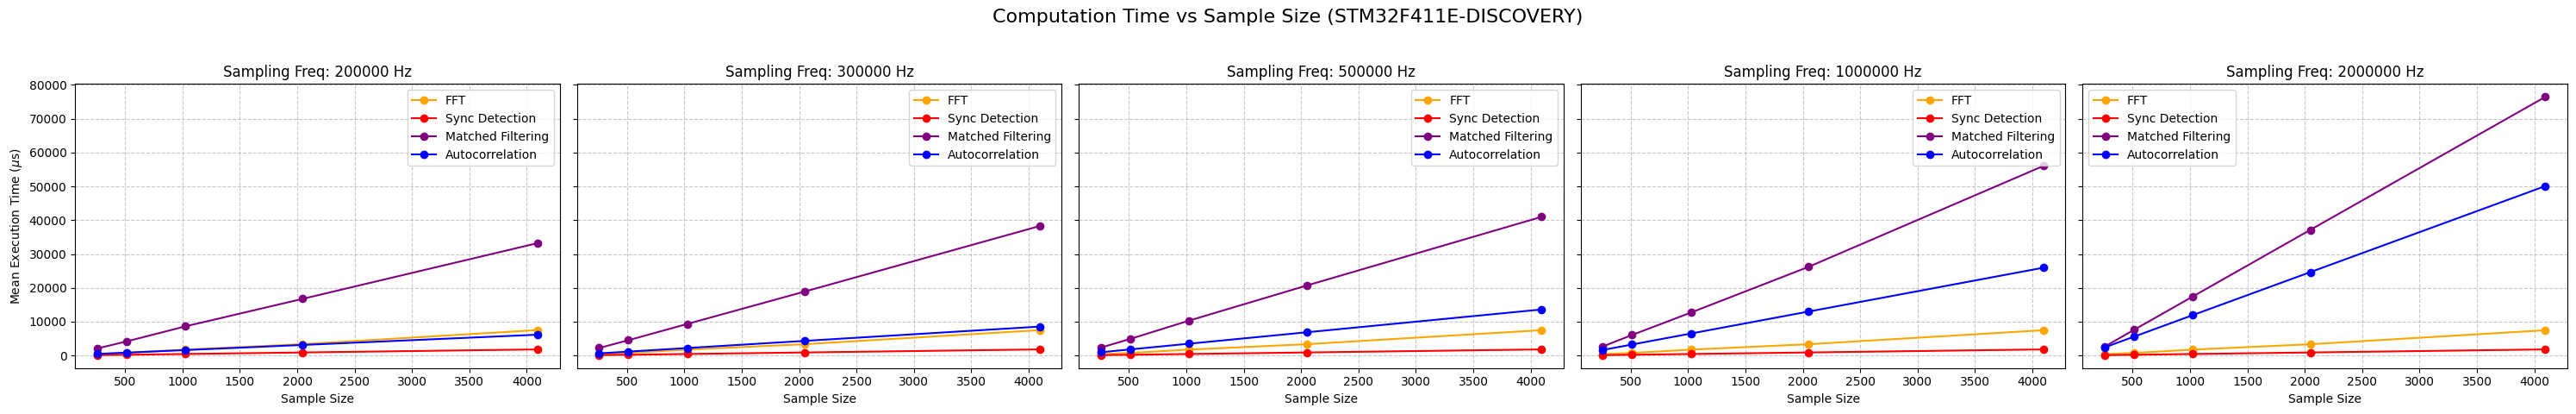

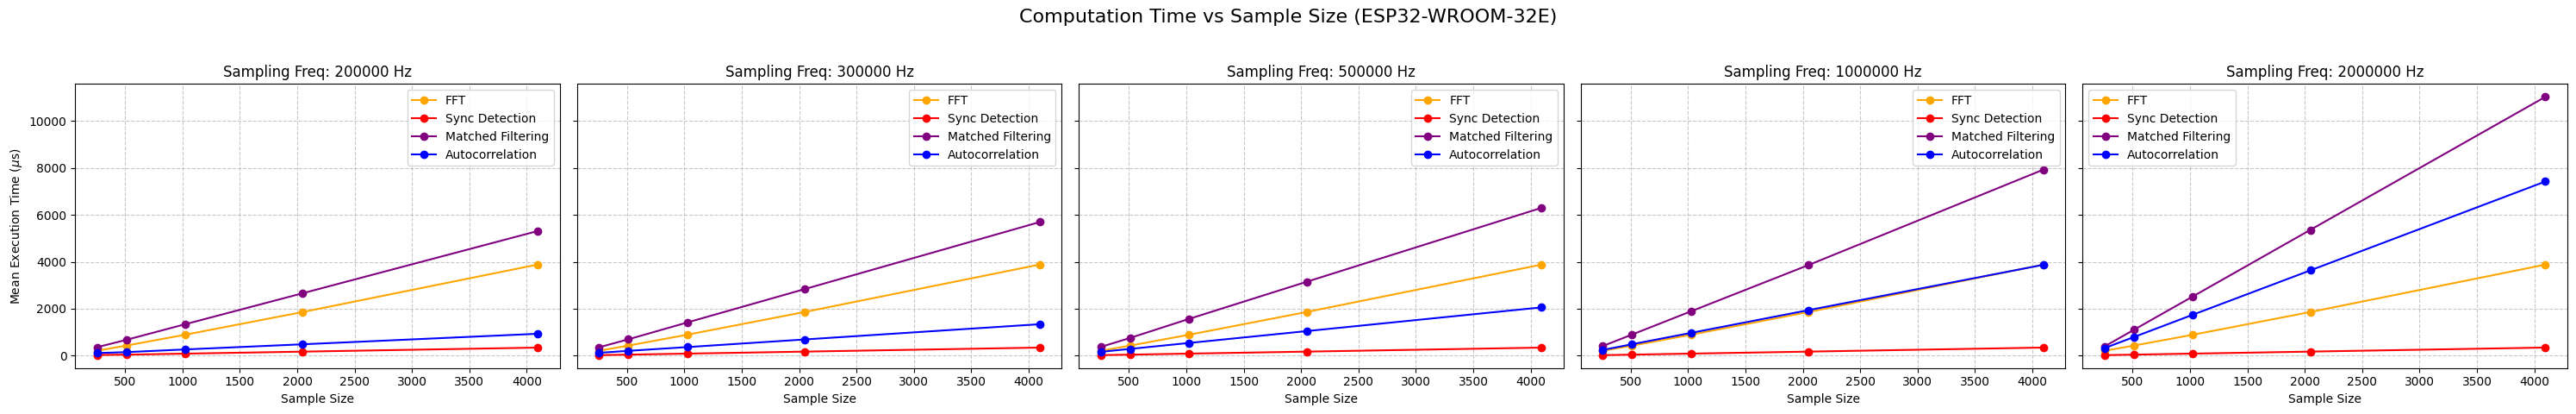

In [48]:
def plot_size_dependency_by_fs(df, board):
    board_df = df[df['board'] == board]
    sampling_freqs = sorted(board_df['fs'].unique())
    
    fig, axes = plt.subplots(1, len(sampling_freqs), figsize=(6 * len(sampling_freqs), 5), sharey=True)
    if len(sampling_freqs) == 1: axes = [axes]
    
    for i, fs in enumerate(sampling_freqs):
        ax = axes[i]
        fs_df = board_df[board_df['fs'] == fs]
        
        for method, (display_name, color) in method_mapping.items():
            method_data = fs_df[fs_df['method'] == method].sort_values('size')
            if not method_data.empty:
                ax.plot(method_data['size'], method_data['mean_time_us'], 
                        marker='o', label=display_name, color=color)
        
        ax.set_title(f'Sampling Freq: {fs} Hz')
        ax.set_xlabel('Sample Size')
        if i == 0: ax.set_ylabel('Mean Execution Time ($\mu$s)')
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend()

    plt.suptitle(f'Computation Time vs Sample Size ({board})', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('size_dependency_by_fs.png')

plot_size_dependency_by_fs(df, 'STM32F411E-DISCOVERY')
plot_size_dependency_by_fs(df, 'ESP32-WROOM-32E')

<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
C:\Users\lviv1\AppData\Local\Temp\ipykernel_25880\3899053377.py:49: SyntaxWarning: invalid escape sequence '\m'
  ax.set_zlabel('Time ($\mu$s)')


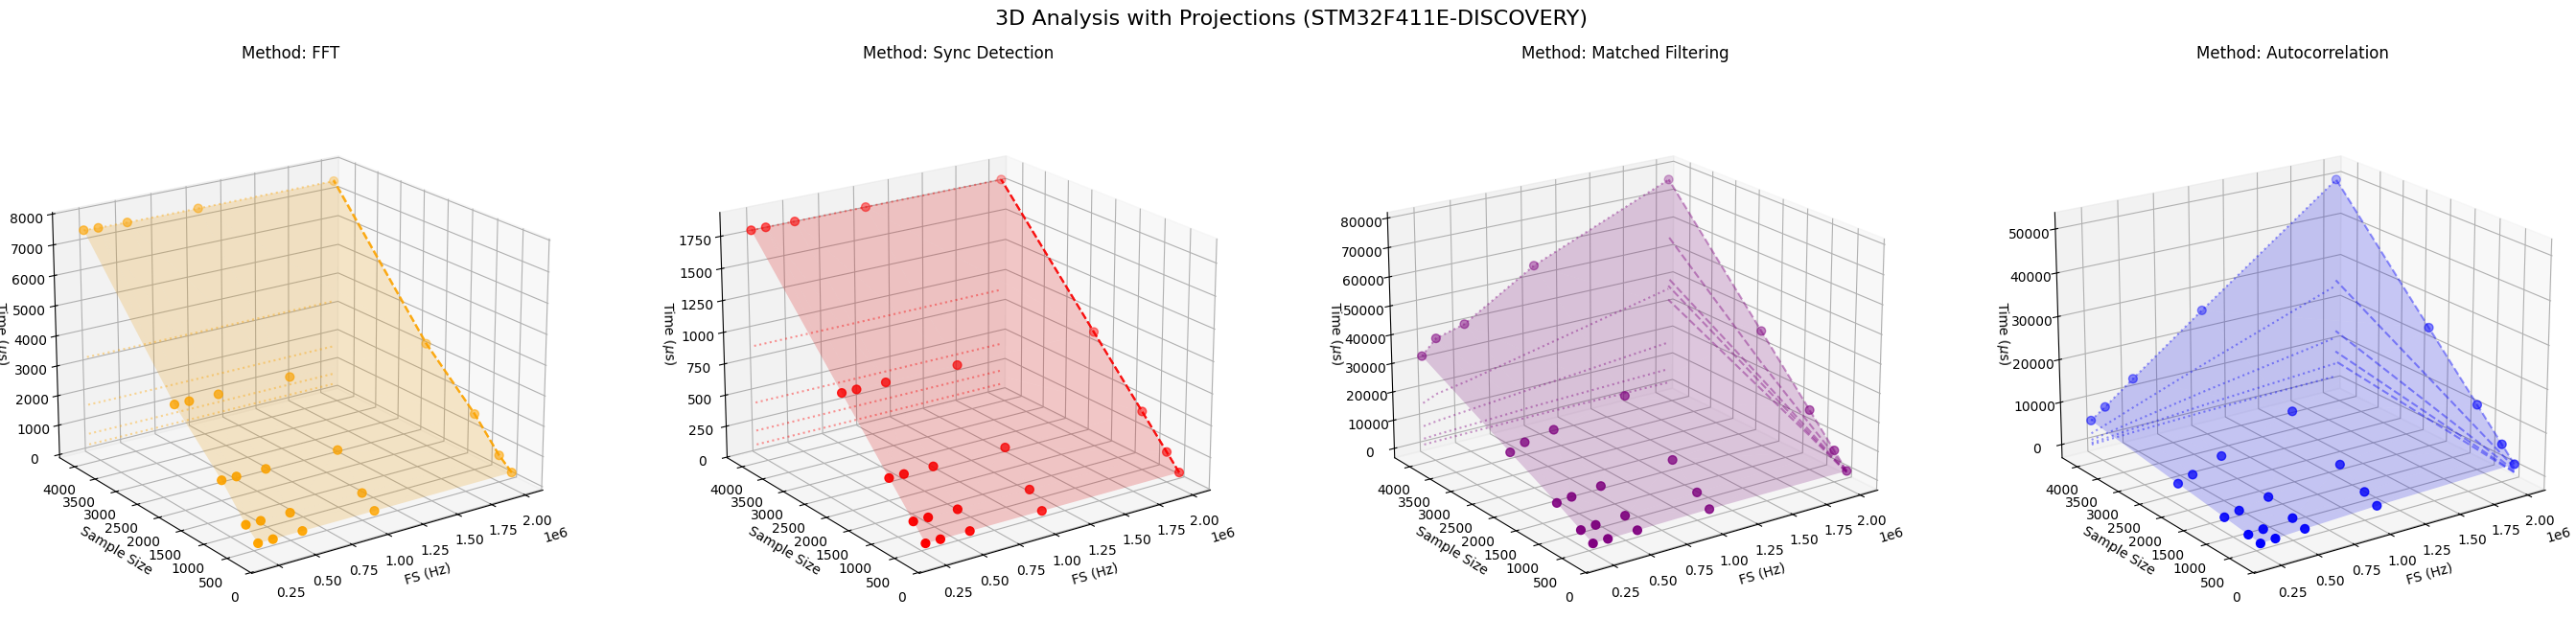

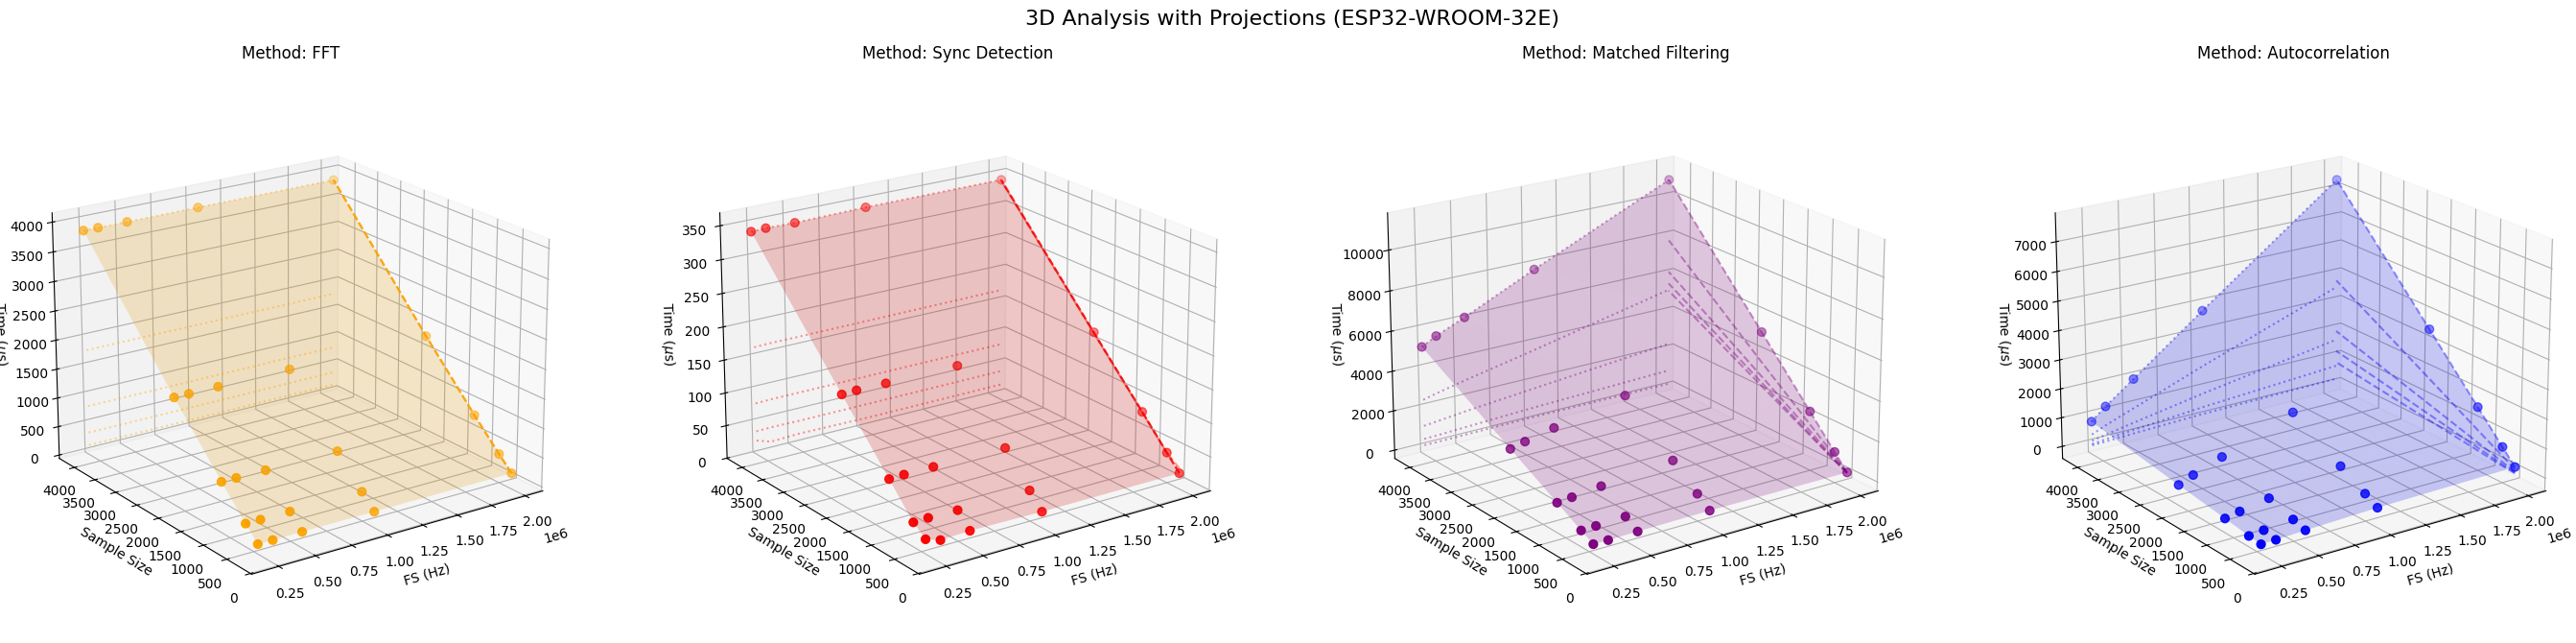

In [62]:
def plot_3d_time_vs_fs_size_by_method(df, board):
    board_df = df[df['board'] == board]
    methods = [m for m in method_mapping.keys() if m in board_df['method'].unique()]
    
    if not methods:
        return

    n_methods = len(methods)
    fig = plt.figure(figsize=(7 * n_methods, 7))
    
    # Calculate global limits for the board to ensure consistent "walls" across subplots
    fs_min, fs_max = board_df['fs'].min(), board_df['fs'].max()
    sz_min, sz_max = board_df['size'].min(), board_df['size'].max()
    t_max = board_df['mean_time_us'].max() * 1.1

    for i, method in enumerate(methods):
        ax = fig.add_subplot(1, n_methods, i + 1, projection='3d')
        m_df = board_df[board_df['method'] == method].copy()
        display_name, color = method_mapping[method]
        
        # 1. Main 3D Data: Scatter and Surface
        ax.scatter(m_df['fs'], m_df['size'], m_df['mean_time_us'], color=color, s=40, depthshade=True)
        try:
            ax.plot_trisurf(m_df['fs'], m_df['size'], m_df['mean_time_us'], color=color, alpha=0.2)
        except:
            pass # Surface requires at least 3 non-collinear points

        # 2. Add Line Projections to the sides
        # Projection on the Side Wall (X = fs_min): Shows Time vs Sample Size
        for f in sorted(m_df['fs'].unique()):
            subset = m_df[m_df['fs'] == f].sort_values('size')
            ax.plot(np.full_like(subset['size'], fs_max), # Fixed at minimum FS
                    subset['size'], 
                    subset['mean_time_us'], 
                    color=color, linestyle='--', alpha=0.4, linewidth=1.5)

        # Projection on the Back Wall (Y = sz_max): Shows Time vs FS
        for s in sorted(m_df['size'].unique()):
            subset = m_df[m_df['size'] == s].sort_values('fs')
            ax.plot(subset['fs'], 
                    np.full_like(subset['fs'], sz_max),  # Fixed at maximum Size
                    subset['mean_time_us'], 
                    color=color, linestyle=':', alpha=0.4, linewidth=1.5)

        # Axis styling
        ax.set_title(f'Method: {display_name}', pad=20)
        ax.set_xlabel('FS (Hz)')
        ax.set_ylabel('Sample Size')
        ax.set_zlabel('Time ($\mu$s)')
        
        # # Set limits to fix the wall positions
        # ax.set_xlim(fs_min, fs_max)
        # ax.set_ylim(sz_min, sz_max)
        # ax.set_zlim(0, t_max)
        
        # Adjust view angle for better perspective of projections
        ax.view_init(elev=20, azim=-125)

    plt.suptitle(f'3D Analysis with Projections ({board})', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])


plot_3d_time_vs_fs_size_by_method(df, 'STM32F411E-DISCOVERY')
plot_3d_time_vs_fs_size_by_method(df, 'ESP32-WROOM-32E')

<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
C:\Users\lviv1\AppData\Local\Temp\ipykernel_16108\91192986.py:47: SyntaxWarning: invalid escape sequence '\m'
  if i == 0: ax1.set_zlabel('Time ($\mu s$)')
C:\Users\lviv1\AppData\Local\Temp\ipykernel_16108\91192986.py:61: SyntaxWarning: invalid escape sequence '\m'
  if i == 0: ax2.set_zlabel('$\mu s / Ops$')
C:\Users\lviv1\AppData\Local\Temp\ipykernel_16108\91192986.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mean_time_us'] = df[trial_cols].mean(axis=1)
C:\Users\lviv1\AppData\Local\Temp\ipykernel_16108\91192986.py:25: SettingWithCopy

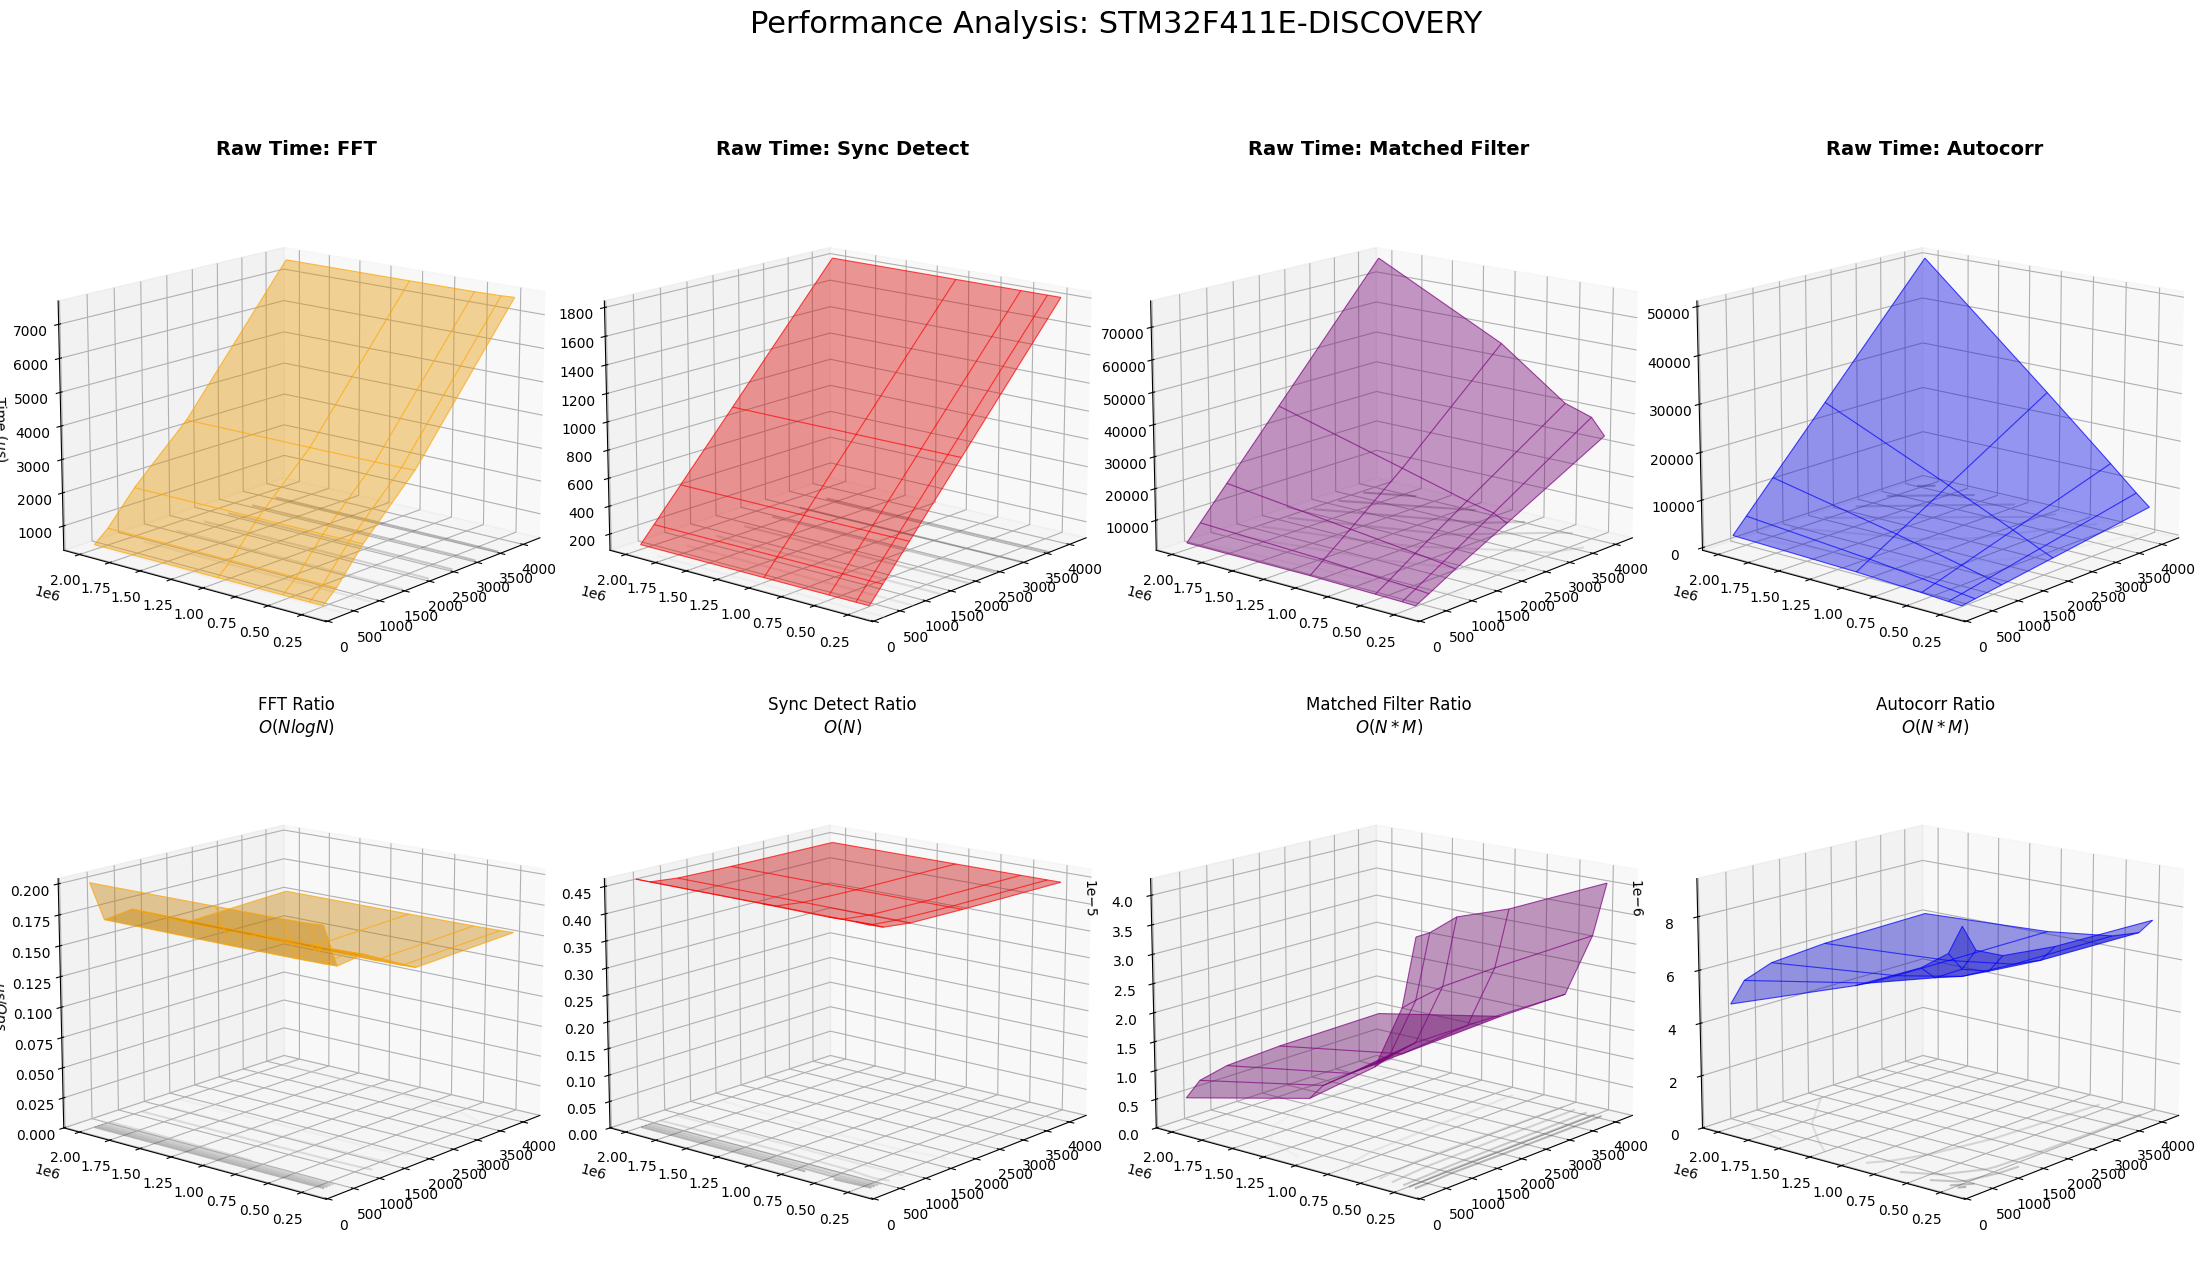

C:\Users\lviv1\AppData\Local\Temp\ipykernel_16108\91192986.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mean_time_us'] = df[trial_cols].mean(axis=1)
C:\Users\lviv1\AppData\Local\Temp\ipykernel_16108\91192986.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ratio'] = df.apply(compute_ratio, axis=1)


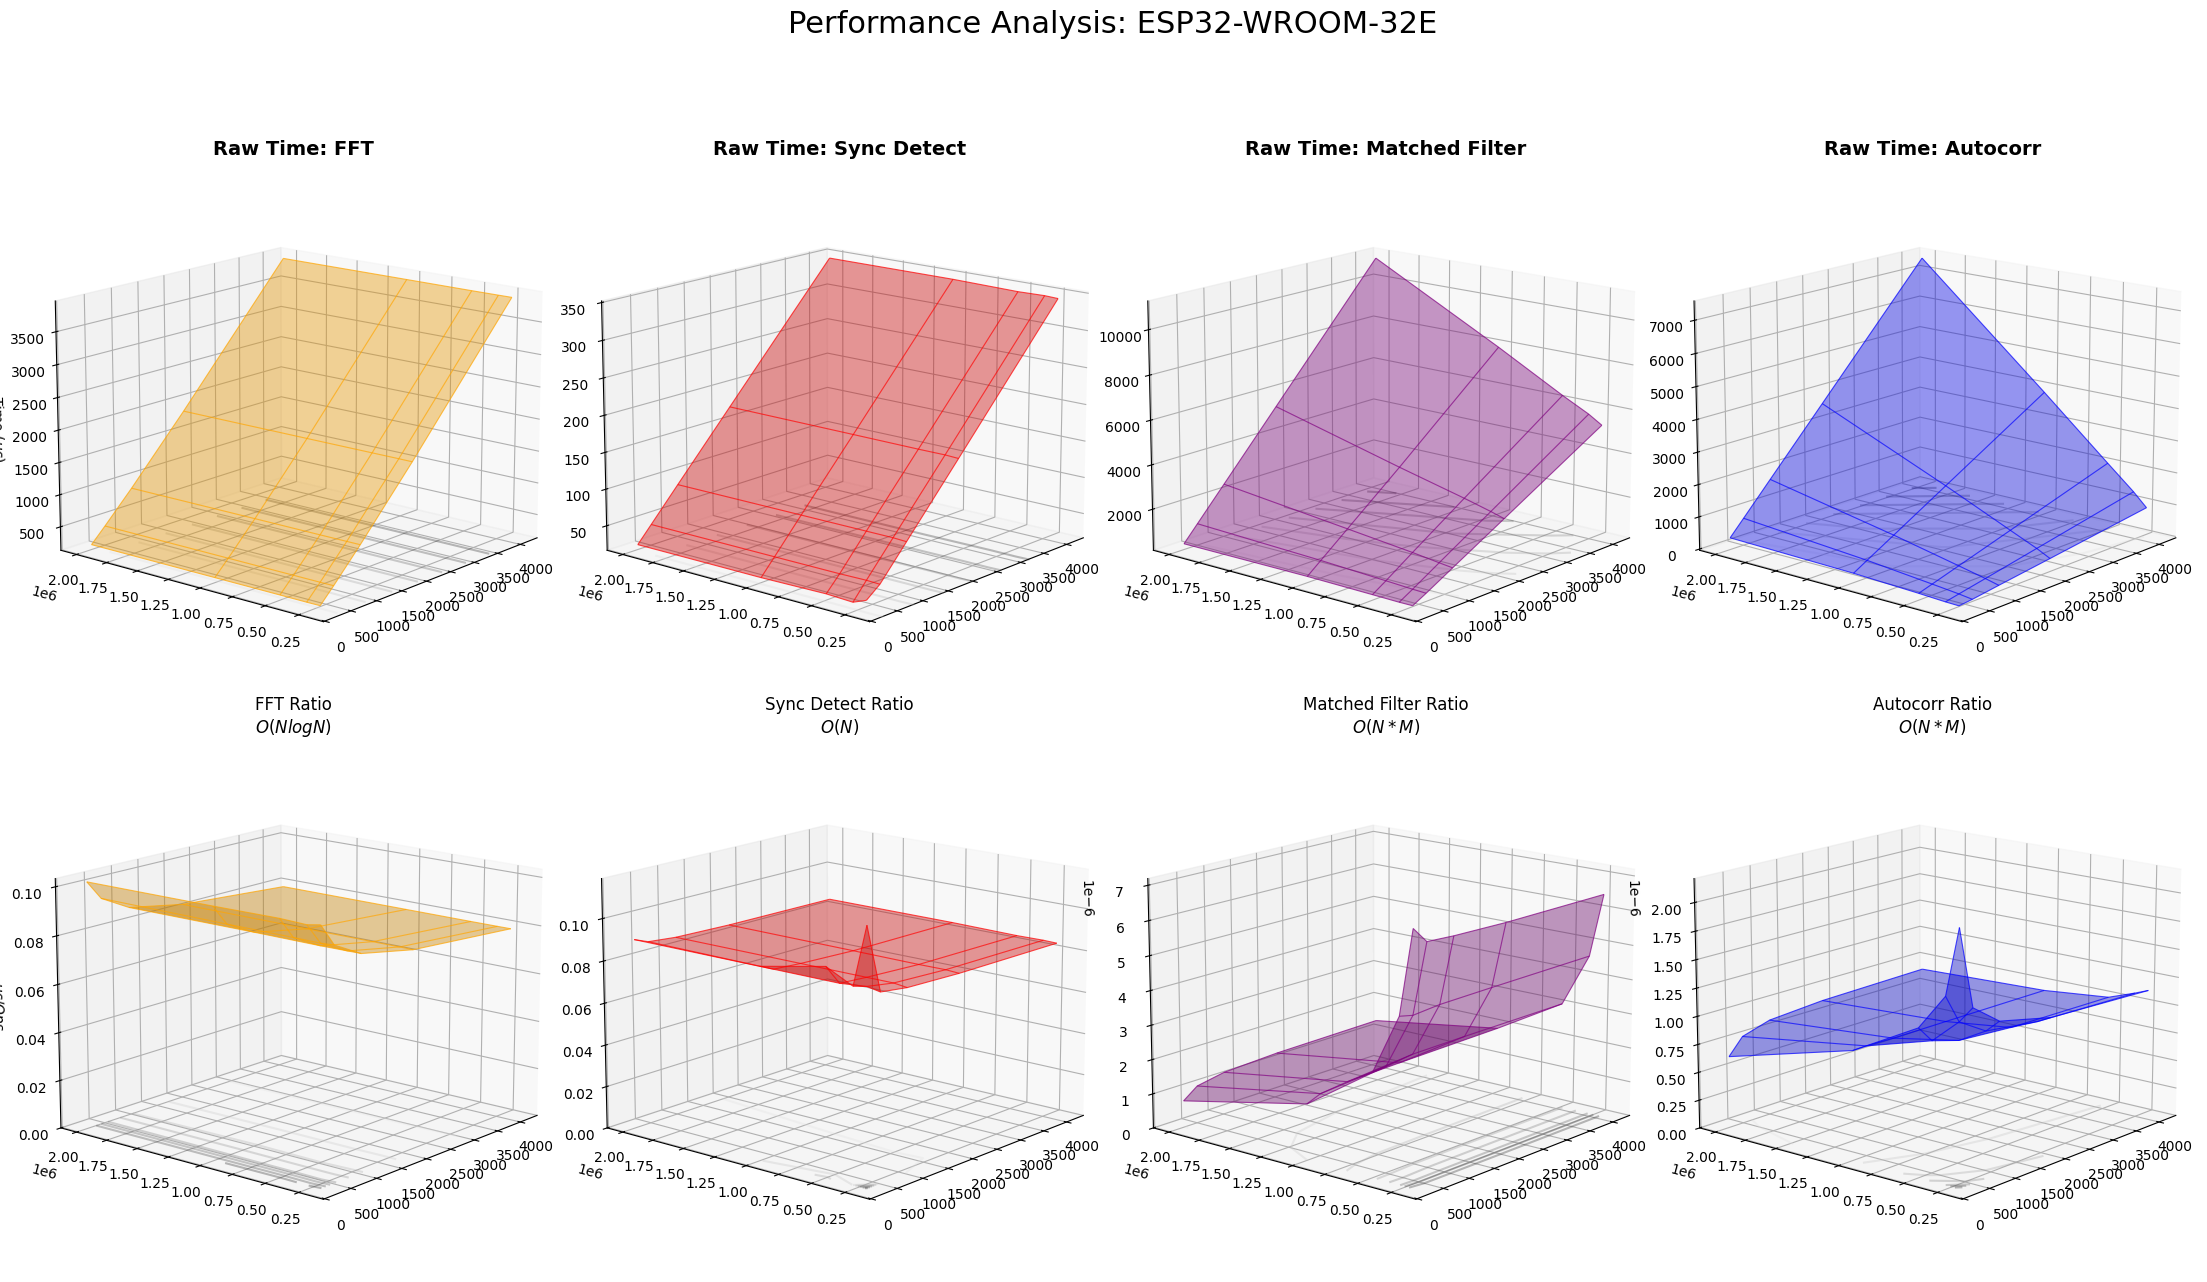

In [24]:
def plot_microcontroller_benchmarks(df, board):
    df = df[df['board'] == board]
    trial_cols = [c for c in df.columns if c.isdigit()]
    df['mean_time_us'] = df[trial_cols].mean(axis=1)

    method_info = {
        'FFT':      {'name': 'FFT', 'color': 'orange', 'label': 'N log N', 
                     'func': lambda n, m: n * np.log2(n)},
        'SYNC':     {'name': 'Sync Detect', 'color': 'red', 'label': 'N', 
                     'func': lambda n, m: n},
        'MATCH':    {'name': 'Matched Filter', 'color': 'purple', 'label': 'N * M', 
                     'func': lambda n, m: n * m},
        'AUTOCORR': {'name': 'Autocorr', 'color': 'blue', 'label': 'N * M', 
                     'func': lambda n, m: n * m}
    }

    def compute_ratio(row):
        m_info = method_info.get(row['method'])
        if m_info:
            n, m = row['size'], row['fs']
            comp_val = m_info['func'](n, m)
            return row['mean_time_us'] / comp_val if comp_val != 0 else np.nan
        return np.nan

    df['ratio'] = df.apply(compute_ratio, axis=1)

    fig = plt.figure(figsize=(22, 14))
    methods = [m for m in method_info.keys() if m in df['method'].unique()]
    elevation, azimuth = 15, -140

    for i, method_key in enumerate(methods):
        info = method_info[method_key]
        subset = df[df['method'] == method_key]

        # --- Plot Row 1: Raw Time ---
        ax1 = fig.add_subplot(2, len(methods), i + 1, projection='3d')
        piv_time = subset.pivot_table(index='fs', columns='size', values='mean_time_us', aggfunc='mean').fillna(0)
        X, Y = np.meshgrid(piv_time.columns, piv_time.index)
        Z1 = piv_time.values

        ax1.plot_surface(X, Y, Z1, color=info['color'], alpha=0.4)
        ax1.plot_wireframe(X, Y, Z1, color=info['color'], alpha=0.7, linewidth=0.8)
        ax1.contour(X, Y, Z1, zdir='z', offset=0, cmap='binary', alpha=0.3)
        
        ax1.set_title(f"Raw Time: {info['name']}", fontsize=14, fontweight='bold')
        ax1.view_init(elev=elevation, azim=azimuth)
        if i == 0: ax1.set_zlabel('Time ($\mu s$)')

        # --- Plot Row 2: Complexity Ratio ---
        ax2 = fig.add_subplot(2, len(methods), i + 1 + len(methods), projection='3d')
        piv_ratio = subset.pivot_table(index='fs', columns='size', values='ratio', aggfunc='mean').fillna(0)
        Z2 = piv_ratio.values

        ax2.plot_surface(X, Y, Z2, color=info['color'], alpha=0.4)
        ax2.plot_wireframe(X, Y, Z2, color=info['color'], alpha=0.7, linewidth=0.8)
        ax2.contour(X, Y, Z2, zdir='z', offset=0, cmap='binary', alpha=0.3)
        
        ax2.set_zlim(0, None) # Crucial for Big-O validation
        ax2.set_title(f"{info['name']} Ratio\n$O({info['label']})$", fontsize=12)
        ax2.view_init(elev=elevation, azim=azimuth)
        if i == 0: ax2.set_zlabel('$\mu s / Ops$')

    plt.suptitle(f'Performance Analysis: {board}', fontsize=22, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
 
    plt.show()

plot_microcontroller_benchmarks(df, 'STM32F411E-DISCOVERY')
plot_microcontroller_benchmarks(df, 'ESP32-WROOM-32E')